<a href="https://colab.research.google.com/github/VrishankDesai/ML-and-Self-Driving-cars-using-python/blob/main/Machine_Learning_and_Self_driving_cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()  # select archive.zip from your computer

import zipfile
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("road_signs")

import os
print(os.listdir("road_signs"))
print(os.listdir("road_signs/images")[:5])
print(os.listdir("road_signs/annotations")[:5])

Saving archive.zip to archive.zip
['annotations', 'images']
['road836.png', 'road32.png', 'road738.png', 'road789.png', 'road402.png']
['road452.xml', 'road712.xml', 'road194.xml', 'road502.xml', 'road30.xml']


In [2]:
import torch
import torchvision
import xml.etree.ElementTree as ET
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
CLASSES = ["background", "speedlimit", "stop", "crosswalk", "trafficlight"]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}

def parse_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes, labels = [], []
    for obj in root.findall("object"):
        label = obj.find("name").text
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)
    return boxes, labels

In [4]:
class RoadSignDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transforms=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.imgs = sorted(os.listdir(img_dir))
        self.transforms = transforms

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        ann_path = os.path.join(self.ann_dir, img_name.replace(".png", ".xml"))

        img = Image.open(img_path).convert("RGB")
        boxes, labels = parse_annotation(ann_path)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor([CLASS_TO_IDX[l] for l in labels], dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [5]:
transform = T.Compose([T.ToTensor()])
dataset = RoadSignDataset("road_signs/images", "road_signs/annotations", transforms=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, collate_fn=collate_fn)

print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}")

Train size: 701, Val size: 176


In [6]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = len(CLASSES)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)
print("Model ready")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 78.2MB/s]


Model ready


In [7]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for imgs, targets in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/10 - Loss: 0.1943
Epoch 2/10 - Loss: 0.0827
Epoch 3/10 - Loss: 0.0646
Epoch 4/10 - Loss: 0.0538
Epoch 5/10 - Loss: 0.0496
Epoch 6/10 - Loss: 0.0440
Epoch 7/10 - Loss: 0.0377
Epoch 8/10 - Loss: 0.0342
Epoch 9/10 - Loss: 0.0339
Epoch 10/10 - Loss: 0.0326


In [8]:
!pip install -q torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric = MeanAveragePrecision(iou_type="bbox")
model.eval()

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = [img.to(device) for img in imgs]
        preds = model(imgs)
        preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        metric.update(preds, targets_cpu)

result = metric.compute()
print(f"mAP: {result['map'].item():.4f}")
print(f"mAP@50: {result['map_50'].item():.4f}")
print(f"mAP@75: {result['map_75'].item():.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.4 MB/s eta 0:00:00
mAP: 0.7343
mAP@50: 0.9355
mAP@75: 0.8420


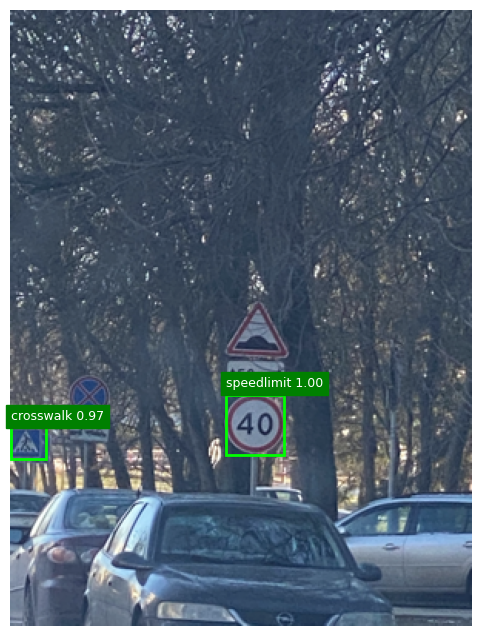

In [9]:
model.eval()
img, target = val_ds[0]

with torch.no_grad():
    prediction = model([img.to(device)])[0]

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img.permute(1, 2, 0))

for box, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
    if score > 0.5:
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{CLASSES[label]} {score:.2f}", color='white', backgroundcolor='green', fontsize=9)

plt.axis('off')
plt.show()

In [10]:
torch.save(model.state_dict(), "road_sign_detector.pth")
files.download("road_sign_detector.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>